In [3]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt
import pandas as pd
def simulate_pid(G, Kp, Ki, Kd):
    # Create PID controller

    C = ctrl.TransferFunction(
        [Kd, Kp, Ki],
        [1, 0]
    )

    # Closed-loop system

    T = ctrl.feedback(C * G, 1)

    # Step response

    t = np.linspace(0, 20, 1000)

    t, y = ctrl.step_response(T, T=t)

    # Performance metrics

    try:

        info = ctrl.step_info(T)

        rise_time = info["RiseTime"]
        settling_time = info["SettlingTime"]
        overshoot = info["Overshoot"]
        peak = info["Peak"]
        peak_time = info["PeakTime"]
        steady_state = info["SteadyStateValue"]

        steady_state_error = abs(1 - steady_state)

    except Exception:

        rise_time = np.nan
        settling_time = np.nan
        overshoot = np.nan
        peak = np.nan
        peak_time = np.nan
        steady_state = np.nan
        steady_state_error = np.nan

    return {
        "Kp": Kp,
        "Ki": Ki,
        "Kd": Kd,
        "time": t,
        "response": y,
        "rise_time": rise_time,
        "settling_time": settling_time,
        "overshoot": overshoot,
        "peak": peak,
        "peak_time": peak_time,
        "steady_state": steady_state,
        "steady_state_error": steady_state_error
    }

# G(s) = 1/(s+1)

G = ctrl.TransferFunction(
    [1],
    [1, 1]
)


# PID

result = simulate_pid(
    G,
    Kp=2,
    Ki=1,
    Kd=0.5
)

# Print Results

print("Kp =", result["Kp"])
print("Ki =", result["Ki"])
print("Kd =", result["Kd"])

print("\nPerformance:")
print("Rise Time =", result["rise_time"])
print("Settling Time =", result["settling_time"])
print("Overshoot =", result["overshoot"])
print("Peak =", result["peak"])
print("Peak Time =", result["peak_time"])
print("Steady State =", result["steady_state"])
print("Steady State Error =", result["steady_state_error"])

Kp = 2
Ki = 1
Kd = 0.5

Performance:
Rise Time = 2.9716226314905083
Settling Time = 6.72985125366968
Overshoot = 0.0
Peak = 0.9996666666645435
Peak Time = 16.343924473197795
Steady State = 1.0
Steady State Error = 0.0


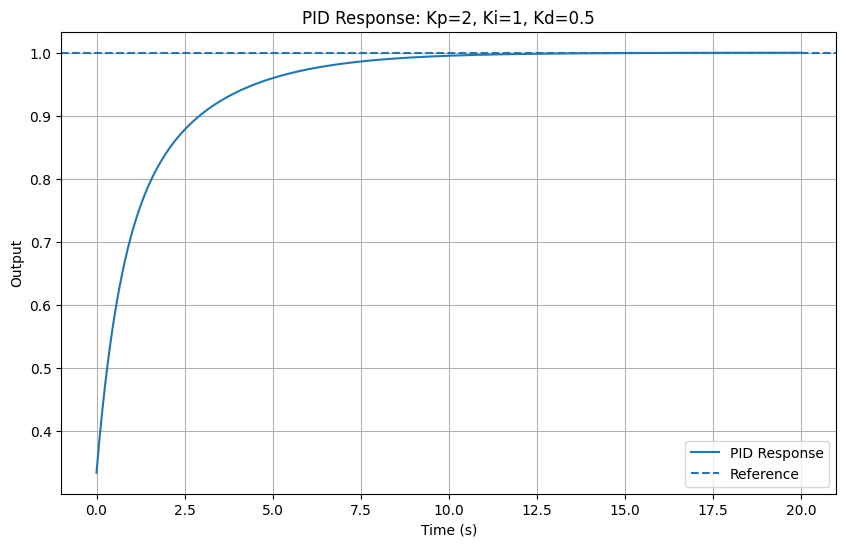

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(
    result["time"],
    result["response"],
    label="PID Response"
)

plt.axhline(
    1,
    linestyle="--",
    label="Reference"
)

plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.title(
    f"PID Response: "
    f"Kp={result['Kp']}, "
    f"Ki={result['Ki']}, "
    f"Kd={result['Kd']}"
)

plt.grid()
plt.legend()

plt.show()

In [2]:
# Vary Kp
Kp_values = [0.5, 1, 2, 5, 10]

for Kp in Kp_values:

    result = simulate_pid(
        G,
        Kp,
        Ki=1,
        Kd=0.5
    )

    print(
        Kp,
        result["rise_time"],
        result["settling_time"],
        result["overshoot"]
    )

0.5 2.791012233932176 6.977530584830441 5.848225342669
1 2.8258998868563285 3.9771924333533515 0.8964483401511458
2 2.9716226314905083 6.72985125366968 0.0
5 2.3827883090039648 11.62511871968601 0.0
10 0.47693468950064644 15.681612590781256 0.0


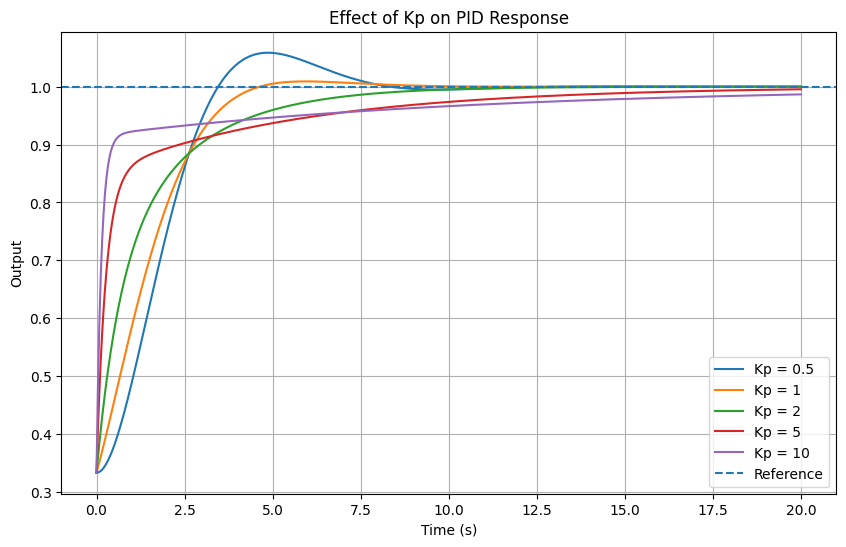

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl


def simulate_pid(G, Kp, Ki, Kd):

    C = ctrl.TransferFunction(
        [Kd, Kp, Ki],
        [1, 0]
    )

    T = ctrl.feedback(C * G, 1)

    t = np.linspace(0, 20, 1000)

    t, y = ctrl.step_response(T, T=t)

    return t, y


# Plant
G = ctrl.TransferFunction(
    [1],
    [1, 1]
)


# Different Kp values
Kp_values = [0.5, 1, 2, 5, 10]


plt.figure(figsize=(10, 6))


for Kp in Kp_values:

    t, y = simulate_pid(
        G,
        Kp=Kp,
        Ki=1,
        Kd=0.5
    )

    plt.plot(
        t,
        y,
        label=f"Kp = {Kp}"
    )


plt.axhline(
    1,
    linestyle="--",
    label="Reference"
)

plt.xlabel("Time (s)")
plt.ylabel("Output")

plt.title("Effect of Kp on PID Response")

plt.grid()
plt.legend()

plt.show()

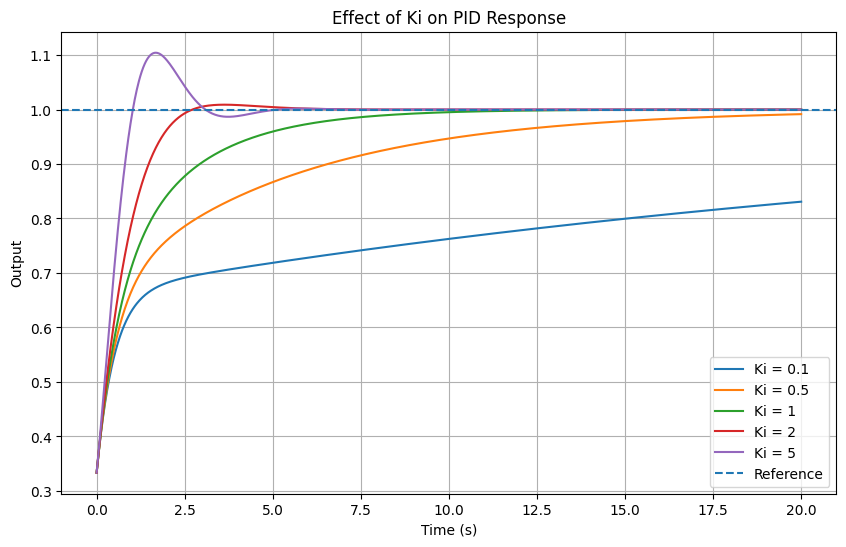

In [6]:
# Varuy Ki
Ki_values = [0.1, 0.5, 1, 2, 5]

plt.figure(figsize=(10, 6))

for Ki in Ki_values:

    t, y = simulate_pid(
        G,
        Kp=2,
        Ki=Ki,
        Kd=0.5
    )

    plt.plot(
        t,
        y,
        label=f"Ki = {Ki}"
    )


plt.axhline(
    1,
    linestyle="--",
    label="Reference"
)

plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.title("Effect of Ki on PID Response")

plt.grid()
plt.legend()

plt.show()

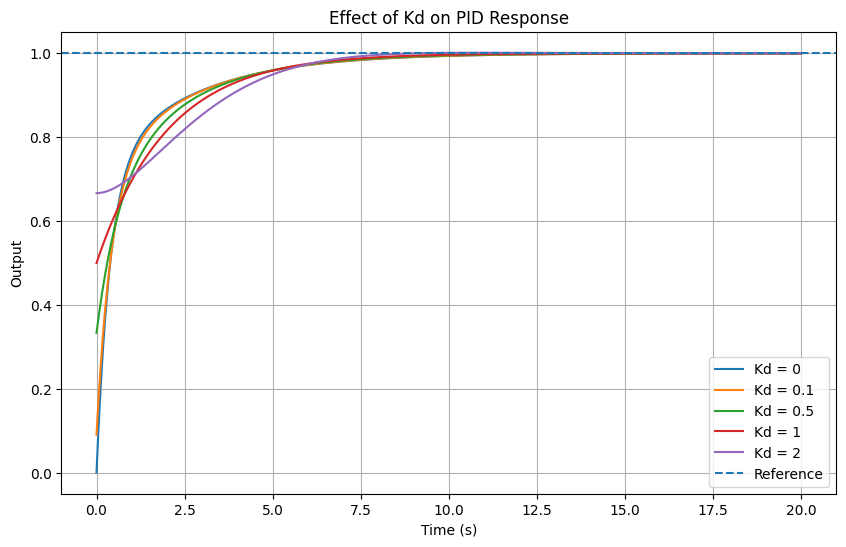

In [7]:
# Vary Kd
Kd_values = [0, 0.1, 0.5, 1, 2]

plt.figure(figsize=(10, 6))

for Kd in Kd_values:

    t, y = simulate_pid(
        G,
        Kp=2,
        Ki=1,
        Kd=Kd
    )

    plt.plot(
        t,
        y,
        label=f"Kd = {Kd}"
    )


plt.axhline(
    1,
    linestyle="--",
    label="Reference"
)

plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.title("Effect of Kd on PID Response")

plt.grid()
plt.legend()

plt.show()

In [ ]:
# Vary all parameters simultaneously
def evaluate_pid(G, Kp, Ki, Kd):

    C = ctrl.TransferFunction(
        [Kd, Kp, Ki],
        [1, 0]
    )

    T = ctrl.feedback(C * G, 1)

    try:

        info = ctrl.step_info(T)

        rise_time = info["RiseTime"]
        settling_time = info["SettlingTime"]
        overshoot = info["Overshoot"]
        peak = info["Peak"]
        peak_time = info["PeakTime"]
        steady_state = info["SteadyStateValue"]

        steady_state_error = abs(
            1 - steady_state
        )

    except Exception:

        rise_time = np.nan
        settling_time = np.nan
        overshoot = np.nan
        peak = np.nan
        peak_time = np.nan
        steady_state = np.nan
        steady_state_error = np.nan


    return {
        "Kp": Kp,
        "Ki": Ki,
        "Kd": Kd,
        "RiseTime": rise_time,
        "SettlingTime": settling_time,
        "Overshoot": overshoot,
        "Peak": peak,
        "PeakTime": peak_time,
        "SteadyState": steady_state,
        "SteadyStateError": steady_state_error
    }

# Parameters

Kp_values = [0.5, 1, 2, 5]
Ki_values = [0.1, 0.5, 1, 2]
Kd_values = [0.0, 0.1, 0.5, 1]


# Evaluate

results = []


for Kp in Kp_values:
    for Ki in Ki_values:
        for Kd in Kd_values:
            result = evaluate_pid(G, Kp, Ki, Kd)
            results.append(result)


print("Number of experiments:", len(results))

Number of experiments: 64


In [10]:
# Store in csv

df = pd.DataFrame(results)

df.to_csv(
    "first_order_pid_parameter_results.csv",
    index=False
)

In [11]:
# For second order systems
# G(s) = 1/(s^2 + 2s + 3)
G1 = ctrl.TransferFunction(
    [1],
    [1, 2, 3]
)
results1 = []

for Kp in Kp_values:
    for Ki in Ki_values:
        for Kd in Kd_values:
            result = evaluate_pid(G1, Kp, Ki, Kd)
            results1.append(result)


df = pd.DataFrame(results)

df.to_csv(
    "second_order_pid_parameter_results.csv",
    index=False
)


In [12]:
#For third order systems
# G(s) = s+2)/(s^3 - 3s^2 + 4s + 2)
G2 = ctrl.TransferFunction(
    [1, 2],
    [1, -3, 4, 2]
)

results2 = []

for Kp in Kp_values:
    for Ki in Ki_values:
        for Kd in Kd_values:
            result = evaluate_pid(G1, Kp, Ki, Kd)
            results2.append(result)


df = pd.DataFrame(results)

df.to_csv(
    "third_order_pid_parameter_results.csv",
    index=False
)